## **Predictive Maintenance & Remaining Useful Life (RUL) Forecasting Platform**

# 1. Dataset Loading

This project uses the NASA CMAPSS dataset for predictive maintenance.
The dataset contains multivariate sensor readings from turbofan engines.
Objective: predict Remaining Useful Life (RUL) before engine failure.

# Executive Summary
This project builds a predictive maintenance system using machine learning to predict engine failures before they occur. Using the NASA CMAPSS dataset, the model predicts Remaining Useful Life (RUL), detects anomalies, and recommends maintenance actions to reduce downtime and maintenance cost.

# Project Workflow
Data Collection → Data Preprocessing → Feature Engineering → Model Training → RUL Prediction → Anomaly Detection → Maintenance Recommendation

# 2. Loading the Dataset

In this step, I loaded the NASA CMAPSS dataset into a Pandas DataFrame to begin analysis.

Since the original dataset does not contain column names, I manually assigned meaningful labels such as **unit_id**, **cycle**, operational settings, and sensor names (**sensor1 to sensor21**) to make the data easier to understand and work with.

The raw text file also contained a few extra empty columns, so those were removed to keep only the valid 26 columns.

Finally, I checked the shape of the dataset to confirm that the data was loaded correctly and to understand how many rows and features were available for further processing.

In [3]:
import pandas as pd

columns = ['unit_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)
train = train.iloc[:, :26]
train.columns = columns
print("Shape:", train.shape)
train.head()

Shape: (20631, 26)


,unit_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Checking Dataset Size

Here, I checked the shape of the dataset to see how much data is available for the project.

The output shows the number of rows and columns:

* **Rows** represent total sensor readings collected from all engines.
* **Columns** represent features such as engine ID, cycle number, operating settings, and sensor values.

This helps me understand the size of the dataset before moving to preprocessing and model building.


In [4]:
print(train.shape)

(20631, 26)


### Calculating Remaining Useful Life (RUL)

In this step, I created the **RUL (Remaining Useful Life)** column, which is the main target for this project.

RUL tells us **how many cycles are left before an engine fails**.

To calculate this, I first found the maximum cycle for each engine, which represents the failure point. Then, for every row, I subtracted the current cycle from that maximum cycle.

For example, if an engine fails at cycle 200 and the current cycle is 180, then the RUL is 20. This means the engine has around 20 cycles left before failure.

This RUL value will be used later to train the machine learning model for failure prediction.


In [5]:
max_cycles = train.groupby('unit_id')['cycle'].max()

train['RUL'] = train.apply(
    lambda row: max_cycles[row['unit_id']] - row['cycle'],
    axis=1
)

train[['unit_id', 'cycle', 'RUL']].head(15)

,unit_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0
5,1,6,186.0
6,1,7,185.0
7,1,8,184.0
8,1,9,183.0
9,1,10,182.0


### Viewing the Calculated RUL Values

After creating the RUL column, I displayed the first few rows to verify whether the calculation was correct.

From the output, I can see that as the cycle number increases, the RUL value decreases. This makes sense because an engine gets closer to failure as it runs for more cycles.

This step helped me confirm that the RUL values were generated correctly before moving to further analysis.


In [6]:
print(train[['unit_id', 'cycle', 'RUL']].head(10))

   unit_id  cycle    RUL
0        1      1  191.0
1        1      2  190.0
2        1      3  189.0
3        1      4  188.0
4        1      5  187.0
5        1      6  186.0
6        1      7  185.0
7        1      8  184.0
8        1      9  183.0
9        1     10  182.0


### Checking for Missing Values

Before training the model, I checked whether the dataset contains any missing (null) values.

Missing values can affect model performance and may lead to incorrect predictions if not handled properly.

This step helps ensure that the dataset is clean and ready for further analysis. Since machine learning models work best with complete data, checking for missing values is an important preprocessing step.


In [7]:
print(train.isnull().sum())

unit_id     0
cycle       0
setting1    0
setting2    0
setting3    0
sensor1     0
sensor2     0
sensor3     0
sensor4     0
sensor5     0
sensor6     0
sensor7     0
sensor8     0
sensor9     0
sensor10    0
sensor11    0
sensor12    0
sensor13    0
sensor14    0
sensor15    0
sensor16    0
sensor17    0
sensor18    0
sensor19    0
sensor20    0
sensor21    0
RUL         0
dtype: int64


### Analyzing Engine Lifetime Distribution

In this step, I analyzed how long each engine runs before failure.

I grouped the data by engine ID and found the maximum cycle for each engine, which represents that engine’s total lifetime.

Then, I plotted a histogram to visualize the distribution of engine lifetimes. This graph helps me understand whether most engines fail around similar cycles or if there is large variation between engines.

Studying this pattern gives useful insight into engine degradation behavior and helps in building a better predictive maintenance model.


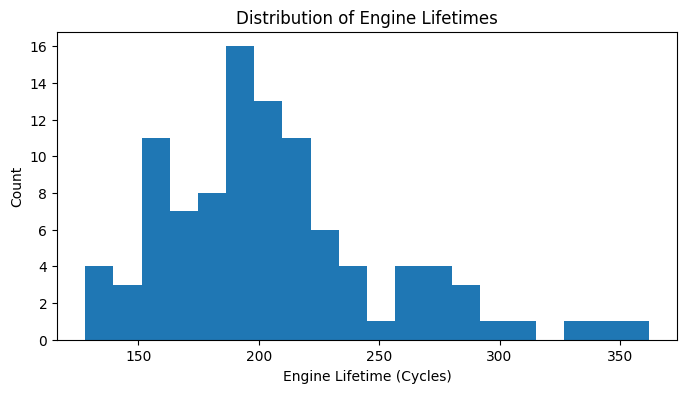

In [8]:
import matplotlib.pyplot as plt

engine_life = train.groupby('unit_id')['cycle'].max()

plt.figure(figsize=(8,4))
plt.hist(engine_life, bins=20)
plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Count")
plt.title("Distribution of Engine Lifetimes")
plt.show()

### Understanding Sensor Behavior Over Time

In this step, I looked at how one sensor changes as the engine runs through more cycles.

I selected **Engine 1** and plotted **Sensor 11** against the cycle number to observe its behavior over time.

This graph helps me understand whether the sensor values stay stable or gradually change as the engine gets older. A clear trend in sensor values can indicate engine degradation and may help in predicting failure earlier.

By analyzing sensor patterns like this, we can identify which sensors are more useful for Remaining Useful Life (RUL) prediction.


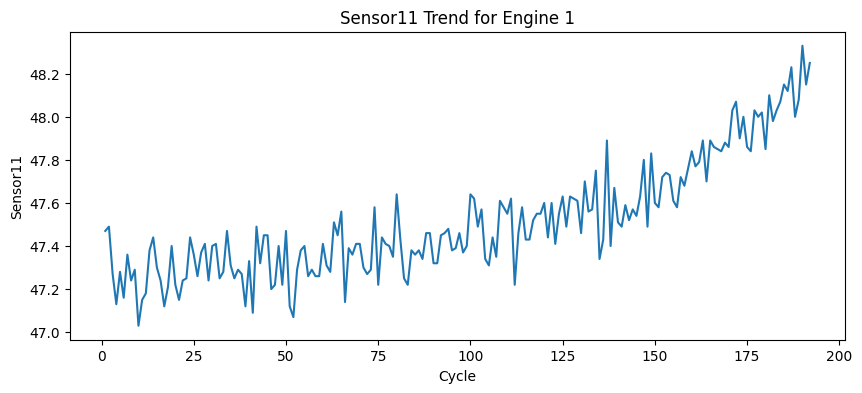

In [9]:
import matplotlib.pyplot as plt

engine1 = train[train['unit_id'] == 1]

plt.figure(figsize=(10,4))
plt.plot(engine1['cycle'], engine1['sensor11'])
plt.xlabel("Cycle")
plt.ylabel("Sensor11")
plt.title("Sensor11 Trend for Engine 1")
plt.show()

### Checking Relationships Between Features

In this step, I created a correlation heatmap to understand how different features are related to each other.

The heatmap shows whether two features move together positively, negatively, or have very little relationship. This helps in identifying which sensor values may strongly influence engine health and RUL prediction.

It also helps detect highly similar features, which can be useful during feature selection and model improvement.


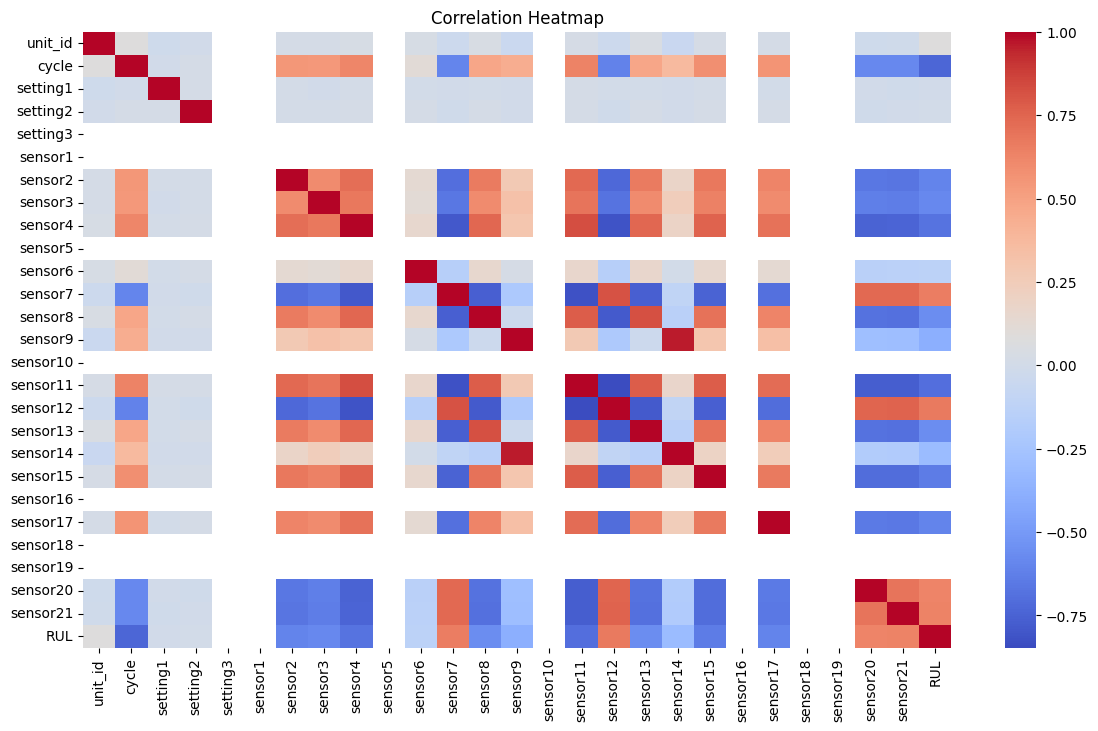

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.heatmap(train.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Finding Constant Features

In this step, I checked for columns where all values remain the same throughout the dataset.

Such features are called **constant features** because they do not change from one row to another. Since they carry no useful information, they do not help the machine learning model make better predictions.

Removing these unnecessary columns helps reduce noise in the data and improves model efficiency.


In [11]:
constant_cols = []

for col in train.columns:
    if train[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


### Removing Unnecessary Features

After identifying the constant columns, I removed them from the dataset.

These features had the same value in every row, so they did not provide any useful information for prediction. Keeping them would only add unnecessary data without improving the model.

By removing these columns, the dataset becomes cleaner and more focused on meaningful features, which helps improve training efficiency and model performance.


In [12]:
train = train.drop(columns=[
    'setting3',
    'sensor1',
    'sensor5',
    'sensor10',
    'sensor16',
    'sensor18',
    'sensor19'
])

print(train.shape)

(20631, 20)


### Preparing Input Features and Target Variable

In this step, I separated the dataset into **input features (X)** and the **target variable (y)**.

The input features include all useful sensor readings and operating settings that help the model learn engine behavior.

The target variable is **RUL (Remaining Useful Life)**, which is what the model needs to predict.

I excluded **unit_id** and **cycle** because they are identifiers and not direct sensor measurements. Finally, I checked the shape of both X and y to confirm the data was prepared correctly for model training.


In [13]:
features = [col for col in train.columns if col not in ['unit_id', 'cycle', 'RUL']]

X = train[features]
y = train['RUL']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20631, 17)
y shape: (20631,)


### Splitting Data for Training and Validation

In this step, I split the dataset into **training data** and **validation data**.

The training data is used to teach the machine learning model how to predict Remaining Useful Life (RUL), while the validation data is used to test how well the model performs on unseen data.

I used an **80-20 split**, where:

* **80%** of the data is used for training
* **20%** of the data is used for validation

This helps evaluate whether the model is learning properly and not just memorizing the training data.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(16504, 17)
(4127, 17)


### Installing Required Library

Before training the model, I installed the **XGBoost** library.

XGBoost is a powerful machine learning algorithm that performs very well on structured data like sensor readings. It is widely used because of its speed, accuracy, and ability to handle complex patterns in data.

This library will be used to build the model for predicting Remaining Useful Life (RUL).


In [15]:
!pip install xgboost

### Training the RUL Prediction Model

In this step, I trained the machine learning model using **XGBoost Regressor** to predict Remaining Useful Life (RUL).

I chose XGBoost because it works well with structured datasets and is known for giving strong prediction performance.

The model was configured with:

* **300 trees (n_estimators)** to improve learning
* **Maximum depth of 6** to capture important patterns
* **Learning rate of 0.05** for stable learning

After setting these parameters, I trained the model using the training data so it could learn the relationship between sensor values and engine health.


In [16]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### Making Predictions on Validation Data

After training the model, I used it to predict the **Remaining Useful Life (RUL)** for the validation dataset.

These predictions represent the model’s estimate of how many cycles each engine has left before failure.

To quickly inspect the results, I displayed the first few predicted values. This helps verify that the model is generating reasonable outputs before evaluating its performance using error metrics.


In [17]:
pred = model.predict(X_val)

print(pred[:10])

[117.879425    8.094909  182.44373     1.0793914 133.34372   103.55451
 121.087265   90.5053     88.7711    154.101    ]


### Evaluating Model Performance

After making predictions, I evaluated how well the model performed by comparing the predicted RUL values with the actual RUL values.

I used two common evaluation metrics:

* **MAE (Mean Absolute Error):** Shows the average difference between predicted and actual values. Lower MAE means better prediction accuracy.
* **RMSE (Root Mean Squared Error):** Measures prediction error while giving more importance to larger mistakes. Lower RMSE indicates a more reliable model.

These metrics help me understand how accurately the model can estimate engine failure time.


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_val, pred)
rmse = mean_squared_error(y_val, pred) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 29.692054336631966
RMSE: 41.56416383115478


### Creating Anomaly Labels

Since the dataset does not directly provide anomaly labels, I created them manually using the RUL values.

I considered engines with **RUL less than 15 cycles** as being in a critical condition and marked them as anomalies.

The labels were assigned as:

* **0 → Normal engine condition**
* **1 → Anomalous / near-failure condition**

This step helps convert the problem into an anomaly detection task, allowing the model to identify engines that are close to failure.


In [19]:
train['anomaly'] = (train['RUL'] < 15).astype(int)

print(train['anomaly'].value_counts())

anomaly
0    19131
1     1500
Name: count, dtype: int64


### Detecting Anomalies Using Isolation Forest

In this step, I used **Isolation Forest** to detect unusual engine behavior from the sensor data.

Isolation Forest is an anomaly detection algorithm that works by identifying data points that behave differently from the majority of normal observations.

I set the contamination value to **0.05**, which means the model assumes around **5% of the data may be anomalous**.

After training, the model predicts whether each data point represents normal engine behavior or a possible anomaly, helping identify engines that may require attention before failure.


In [20]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_pred = iso.fit_predict(X)

In [21]:
anomaly_pred = [1 if x == -1 else 0 for x in anomaly_pred]

In [22]:
print("Detected anomalies:", sum(anomaly_pred))

Detected anomalies: 1032


### Generating Maintenance Recommendations

After predicting the Remaining Useful Life (RUL), the next step is to convert those predictions into practical maintenance actions.

I created a simple rule-based maintenance scheduler:

* If **RUL is less than 7**, the engine needs **immediate maintenance**
* If **RUL is between 7 and 20**, maintenance should be **scheduled soon**
* If **RUL is above 20**, the engine is considered **healthy**

This step helps turn model predictions into real business decisions, allowing maintenance teams to act before failures happen and reduce unexpected downtime.


In [23]:
def maintenance_action(rul):
    if rul < 7:
        return "Immediate Maintenance"
    elif rul < 20:
        return "Schedule This Week"
    else:
        return "Healthy"

sample_rul = [3, 12, 40]

for r in sample_rul:
    print("RUL:", r, "->", maintenance_action(r))

RUL: 3 -> Immediate Maintenance
RUL: 12 -> Schedule This Week
RUL: 40 -> Healthy


### Identifying the Most Important Features

In this step, I analyzed which features had the biggest impact on the model’s predictions.

XGBoost provides a feature importance score for each input feature, showing how much each sensor contributes to predicting Remaining Useful Life (RUL).

I plotted the **top 10 most important features** to better understand which sensors influence engine health the most.

This analysis helps in interpreting the model and gives useful insights into which sensor readings are most critical for predictive maintenance.


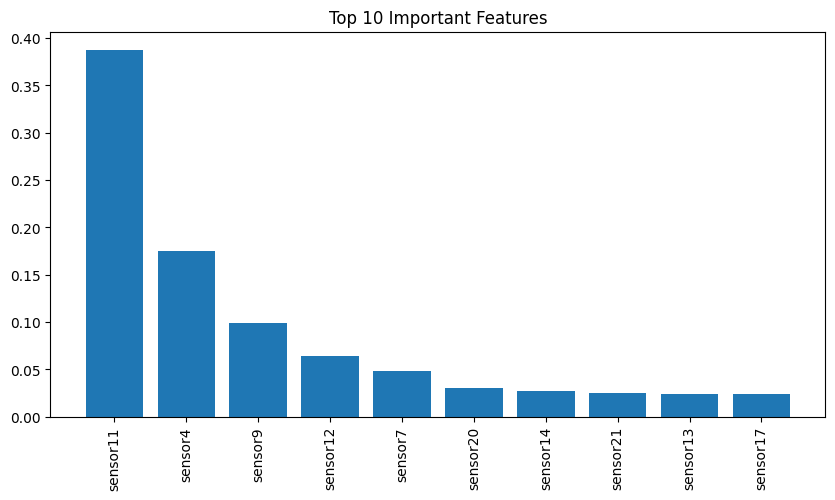

     Feature  Importance
9   sensor11    0.387335
4    sensor4    0.174894
8    sensor9    0.099018
10  sensor12    0.064285
6    sensor7    0.048091
15  sensor20    0.030435
12  sensor14    0.027585
16  sensor21    0.025364
11  sensor13    0.023901
14  sensor17    0.023805


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(feature_imp["Feature"][:10], feature_imp["Importance"][:10])
plt.xticks(rotation=90)
plt.title("Top 10 Important Features")
plt.show()

print(feature_imp.head(10))

### Comparing Actual and Predicted RUL Values

In this step, I compared the actual RUL values with the values predicted by the model.

I created a scatter plot using a sample of validation data to visually check how close the predictions are to the real values.

If the predicted values are close to the actual values, it indicates that the model is performing well. Points that are farther away show prediction errors.

This visualization helps me better understand the accuracy and reliability of the model in predicting engine failure.


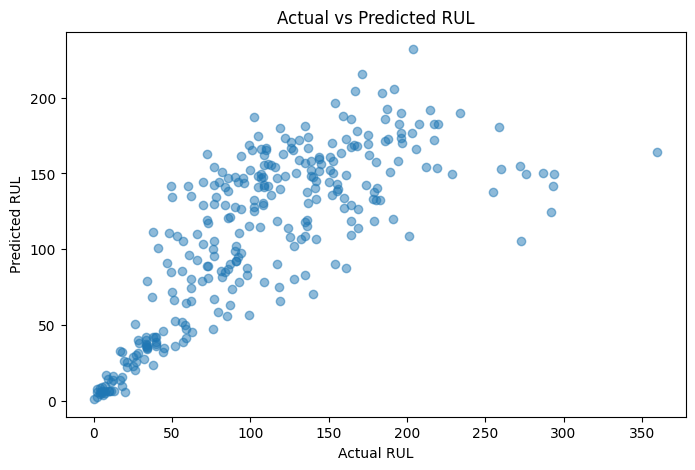

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(y_val[:300], pred[:300], alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

## Final Summary

This project builds a predictive maintenance system using the NASA CMAPSS dataset to predict engine failure before it happens.

Using **XGBoost**, I predicted Remaining Useful Life (RUL) with:

* **MAE:** 29.69 cycles
* **RMSE:** 41.56 cycles

Using **Isolation Forest**, I detected **1032 anomalous engine conditions**.

Based on predicted RUL, maintenance actions were recommended to reduce failure risk and downtime.

Overall, this project shows how machine learning can help industries move from reactive maintenance to proactive maintenance.


## Conclusion

This project successfully predicts engine health using machine learning.
The model estimates Remaining Useful Life, detects anomalies, and provides maintenance recommendations, helping reduce unexpected failures and maintenance costs.


# Personal Reflection
This project helped me understand real-world predictive maintenance systems, feature engineering, anomaly detection, and machine learning model evaluation. It improved my practical skills in solving industrial AI problems.